# Библиотеки

In [47]:
from itertools import combinations
from pprint import pprint

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import statsmodels.stats.stattools as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import add_constant

import seaborn as sns

## 10.10 Линейная регрессия

In [2]:
d = pd.read_spss('./data/SPSS23.sav').set_index('НомерАнкеты')

In [3]:
d.dtypes

Лояльность     float64
Цена           float64
Сервис         float64
Ассортимент    float64
Допуслуги      float64
dtype: object

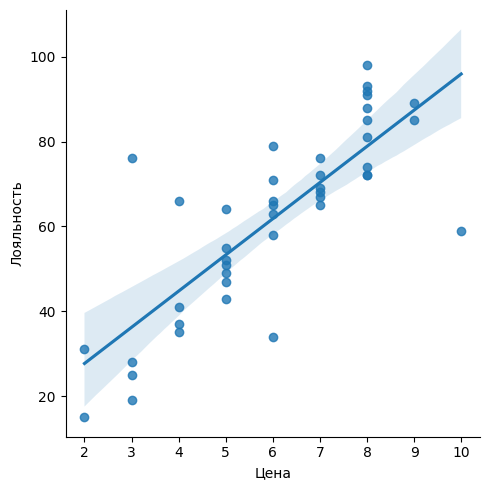

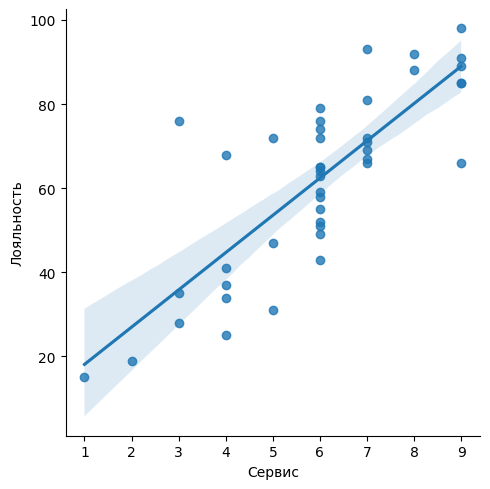

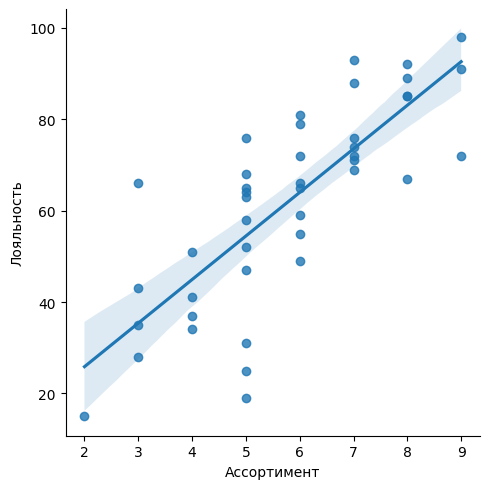

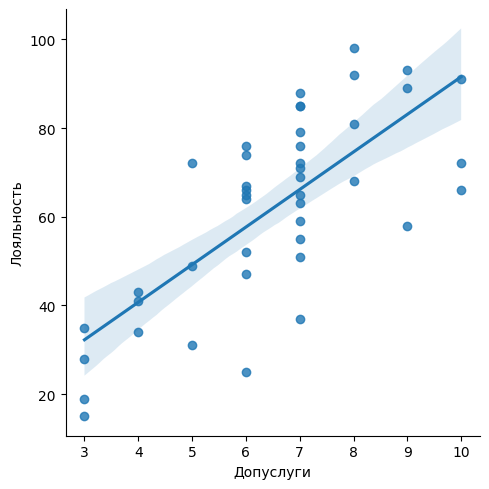

In [4]:
for x in ['Цена','Сервис','Ассортимент','Допуслуги']:
    sns.lmplot(data=d,x=x, y='Лояльность')

In [5]:
for x in ['Цена','Сервис','Ассортимент','Допуслуги']:
    res=pg.linear_regression(d[[x]], d['Лояльность'])
    print(res)

       names       coef        se         T          pval        r2    adj_r2  \
0  Intercept  10.636834  6.309756  1.685776  9.943618e-02  0.642005  0.633273   
1       Цена   8.527476  0.994485  8.574764  1.091824e-10  0.642005  0.633273   

   CI[2.5%]  CI[97.5%]  
0 -2.105978  23.379645  
1  6.519072  10.535879  
       names      coef        se         T          pval        r2    adj_r2  \
0  Intercept  9.243746  6.377719  1.449381  1.548375e-01  0.648384  0.639808   
1     Сервис  8.861402  1.019128  8.695086  7.517373e-11  0.648384  0.639808   

   CI[2.5%]  CI[97.5%]  
0 -3.636319  22.123812  
1  6.803232  10.919572  
         names      coef        se         T          pval        r2   adj_r2  \
0    Intercept  6.794253  7.119700  0.954289  3.455301e-01  0.615352  0.60597   
1  Ассортимент  9.533523  1.177149  8.098821  4.853278e-10  0.615352  0.60597   

   CI[2.5%]  CI[97.5%]  
0 -7.584273  21.172780  
1  7.156221  11.910824  
       names      coef        se         T    

In [6]:
pg.normality(d)

,W,pval,normal
Лояльность,0.964151,0.196322,True
Цена,0.953387,0.079301,True
Сервис,0.936797,0.020020,False
Ассортимент,0.959955,0.138124,True
Допуслуги,0.938048,0.022159,False


In [7]:
pg.pairwise_corr(data=d, columns=[['Лояльность'], ['Цена','Сервис','Ассортимент','Допуслуги']], method='shepherd')

,X,Y,method,alternative,n,outliers,r,CI95%,p-unc,power
0,Лояльность,Цена,shepherd,two-sided,43,2.0,0.910058,"[0.84, 0.95]",1.678882e-16,1.000000
1,Лояльность,Сервис,shepherd,two-sided,43,3.0,0.831526,"[0.7, 0.91]",3.035188e-11,1.000000
2,Лояльность,Ассортимент,shepherd,two-sided,43,3.0,0.850319,"[0.73, 0.92]",3.814172e-12,1.000000
3,Лояльность,Допуслуги,shepherd,two-sided,43,1.0,0.719965,"[0.53, 0.84]",7.697809e-08,0.999915


In [8]:
pg.pairwise_corr(data=d, columns=['Цена','Сервис','Ассортимент','Допуслуги'], method='spearman')

,X,Y,method,alternative,n,r,CI95%,p-unc,power
0,Цена,Сервис,spearman,two-sided,43,0.713578,"[0.53, 0.83]",7.831847e-08,0.999911
1,Цена,Ассортимент,spearman,two-sided,43,0.815226,"[0.68, 0.9]",2.823989e-11,1.000000
2,Цена,Допуслуги,spearman,two-sided,43,0.536030,"[0.28, 0.72]",2.116715e-04,0.968765
3,Сервис,Ассортимент,spearman,two-sided,43,0.721386,"[0.54, 0.84]",4.829811e-08,0.999941
4,Сервис,Допуслуги,spearman,two-sided,43,0.569395,"[0.32, 0.74]",6.754137e-05,0.984974
5,Ассортимент,Допуслуги,spearman,two-sided,43,0.450845,"[0.17, 0.66]",2.412748e-03,0.873497


In [9]:
X = ['Цена','Сервис','Ассортимент','Допуслуги'] # Список независимых переменных
vif_list = [] # Пустой список, куда будут добавляться результаты VIF для каждой переменной

for col in X: # Цикл по каждой независимой переменной из списка X
    others = [c for c in X if c != col] # Cписок остальных переменных, исключая текущую col в конкретной итерации цикла
    res = pg.linear_regression(d[others], d[col]) # Строим линейную регрессию: текущая переменная col как зависимая, остальные переменные как предикторы
    r2 = res.loc[0, 'r2'] # Из результата регрессии извлекаем только значение R2
    vif = 1/(1-r2) if r2<1 else float('inf') # Рассчитываем VIF по формуле 1/(1-R2), но на случай если R2 = 1 ставим бесконечность (деление на ноль)
    vif_list.append({'Variable':col,'R2':r2,'VIF':vif}) # Добавляем словарь с именем переменной, R2 и VIF в список результатов

vif_d = pd.DataFrame(vif_list) # Преобразуем список словарей в DataFrame для наглядного отображения

In [10]:
vif_d

,Variable,R2,VIF
0,Цена,0.656225,2.908877
1,Сервис,0.646624,2.829844
2,Ассортимент,0.639331,2.772624
3,Допуслуги,0.434343,1.767857


In [11]:
z = pg.linear_regression(d[X], d['Лояльность']).round(3)

In [12]:
z

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,-11.966,5.786,-2.068,0.045,0.832,0.814,-23.679,-0.253
1,Цена,2.894,1.207,2.397,0.022,0.832,0.814,0.450,5.338
2,Сервис,2.485,1.231,2.018,0.051,0.832,0.814,-0.008,4.977
3,Ассортимент,3.201,1.346,2.378,0.023,0.832,0.814,0.476,5.926
4,Допуслуги,3.564,1.023,3.484,0.001,0.832,0.814,1.493,5.635


In [13]:
d['pl'] = z['coef'][0]+z['coef'][1]*d['Цена'] + z['coef'][2]*d['Сервис'] + z['coef'][3]*d['Ассортимент'] + z['coef'][4]*d['Допуслуги']

In [14]:
d['R'] = d['Лояльность'] - d['pl']

In [15]:
d.head()

,Лояльность,Цена,Сервис,Ассортимент,Допуслуги,pl,R
НомерАнкеты,,,,,,,
3456,93.0,8.0,7.0,7.0,9.0,83.064,9.936
3457,51.0,5.0,6.0,4.0,7.0,55.166,-4.166
3458,63.0,6.0,6.0,5.0,7.0,61.261,1.739
3459,72.0,7.0,5.0,6.0,10.0,75.563,-3.563
3460,58.0,6.0,6.0,5.0,9.0,68.389,-10.389


In [16]:
pg.normality(d['R']) # Шапиро по умолчанию так как всего 43 наблюдения

,W,pval,normal
R,0.951708,0.068827,True


In [17]:
sm.durbin_watson(d['R'])

np.float64(1.6596799083573022)

In [18]:
het_breuschpagan(d['R'], add_constant(d[['Цена','Сервис','Ассортимент','Допуслуги']]))

(np.float64(10.730247900664867),
 np.float64(0.02976892410717744),
 np.float64(3.158913484755791),
 np.float64(0.02455977843113304))

<Axes: xlabel='R', ylabel='Count'>

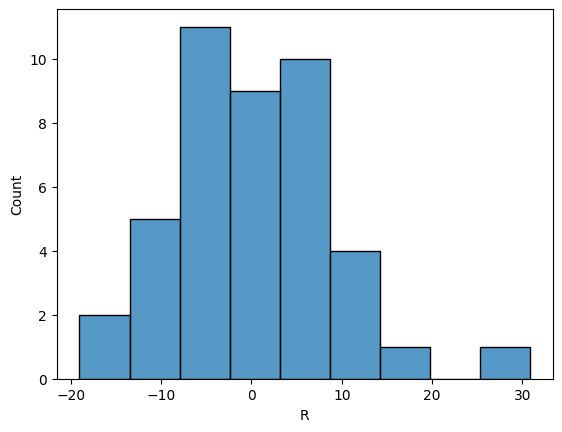

In [19]:
sns.histplot(d['R'])

In [20]:
d['Лояльность'].mean()

np.float64(62.0)

In [21]:
price = 1
service = 1
assortiment = 1
add_services = 1

-11.966 + 2.894*price + 2.485*service + 3.201*assortiment + 3.564*add_services

0.17800000000000038

## 10.11 Понятие нормализации данных

In [22]:
z = pg.linear_regression(d[X],d['Лояльность'], relimp=True)

In [23]:
z

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-11.965955,5.786115,-2.068047,0.045492,0.831906,0.814212,-23.679332,-0.252579,NaN,NaN
1,Цена,2.894127,1.207253,2.397283,0.021539,0.831906,0.814212,0.450172,5.338082,0.216506,26.025231
2,Сервис,2.484593,1.231265,2.017919,0.050701,0.831906,0.814212,-0.007972,4.977159,0.213765,25.695812
3,Ассортимент,3.200823,1.345926,2.378157,0.022532,0.831906,0.814212,0.476138,5.925508,0.205953,24.756803
4,Допуслуги,3.563915,1.022886,3.484178,0.001260,0.831906,0.814212,1.493192,5.634639,0.195682,23.522155


In [24]:
d1 = d[["Цена", "Сервис", "Ассортимент", "Допуслуги"]]

In [25]:
d1 = (d1-d1.mean())/d1.std()
d2 = (d[X]-d[X].mean())/d[X].std()

In [26]:
pg.linear_regression(d1[X], d['Лояльность']).round(3)

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%]
0,Intercept,62.000,1.411,43.926,0.000,0.832,0.814,59.143,64.857
1,Цена,5.839,2.436,2.397,0.022,0.832,0.814,0.908,10.770
2,Сервис,4.848,2.402,2.018,0.051,0.832,0.814,-0.016,9.712
3,Ассортимент,5.655,2.378,2.378,0.023,0.832,0.814,0.841,10.470
4,Допуслуги,6.616,1.899,3.484,0.001,0.832,0.814,2.772,10.460


In [27]:
pg.cronbach_alpha(data=d[X]) # Или можно подать в параметр data такое d[['Цена','Сервис','Ассортимент','Допуслуги']]

(np.float64(0.8790095078884128), array([0.807, 0.929]))

In [28]:
pg.cronbach_alpha(data=d1)

(np.float64(0.8791136269114871), array([0.807, 0.929]))

## 10.13 Квантильная регрессия (библиотека statsmodels)

In [29]:
smf.ols(formula='Лояльность~Цена+Сервис+Ассортимент+Допуслуги', data=d).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Лояльность   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     47.02
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           3.24e-14
Time:                        15:04:51   Log-Likelihood:                -154.04
No. Observations:                  43   AIC:                             318.1
Df Residuals:                      38   BIC:                             326.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -11.9660      5.786     -2.068      0.045     -23.679      -0.253
Цена            2.8941      1.207      2.397      0.022       0.450       5.338
Сервис          2.4846      1.231      2.018      0.051      -0.008       4.977
Ассортимент     3.2008      1.346      2.378      0.023       0.476       5.926
Допуслуги       3.5639      1.023      3.484      0.001       1.493       5.635
==============================================================================
Omnibus:                        9.618   Durbin-Watson:                   1.660
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               11.569
Skew:                           0.685   Prob(JB):                      0.00308
Kurtosis:                       5.140   Cond. No.                         52.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [30]:
formula = "Лояльность ~ Цена + Сервис + Ассортимент + Допуслуги"
model = smf.ols(formula=formula, data=d)   # спецификация
results = model.fit()                      # обучение
results.summary()                          # итоги

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Лояльность   R-squared:                       0.832
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     47.02
Date:                Sun, 04 Jan 2026   Prob (F-statistic):           3.24e-14
Time:                        15:05:14   Log-Likelihood:                -154.04
No. Observations:                  43   AIC:                             318.1
Df Residuals:                      38   BIC:                             326.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept     -11.9660      5.786     -2.068      0.045     -23.679      -0.253
Цена            2.8941      1.207      2.397      0.022       0.450       5.338
Сервис          2.4846      1.231      2.018      0.051      -0.008       4.977
Ассортимент     3.2008      1.346      2.378      0.023       0.476       5.926
Допуслуги       3.5639      1.023      3.484      0.001       1.493       5.635
==============================================================================
Omnibus:                        9.618   Durbin-Watson:                   1.660
Prob(Omnibus):                  0.008   Jarque-Bera (JB):               11.569
Skew:                           0.685   Prob(JB):                      0.00308
Kurtosis:                       5.140   Cond. No.                         52.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
# results.resid # остатки для каждого наблюдения
results.params # параметры модели (имена переменных-предикторов и их коэффициенты)
# results.predict # предсказанные значения Лояльности
# results.model.exog # матрица предикторов с константой

array([[ 1.,  8.,  7.,  7.,  9.],
       [ 1.,  5.,  6.,  4.,  7.],
       [ 1.,  6.,  6.,  5.,  7.],
       [ 1.,  7.,  5.,  6., 10.],
       [ 1.,  6.,  6.,  5.,  9.],
       [ 1.,  8.,  8.,  7.,  7.],
       [ 1.,  5.,  6.,  6.,  7.],
       [ 1.,  3.,  4.,  5.,  6.],
       [ 1.,  2.,  5.,  5.,  5.],
       [ 1.,  8.,  9.,  9., 10.],
       [ 1.,  4.,  4.,  4.,  7.],
       [ 1.,  6.,  7.,  6.,  6.],
       [ 1.,  8.,  6.,  9.,  7.],
       [ 1.,  5.,  6.,  6.,  5.],
       [ 1.,  9.,  9.,  8.,  7.],
       [ 1., 10.,  6.,  6.,  7.],
       [ 1.,  7.,  7.,  8.,  6.],
       [ 1.,  3.,  2.,  5.,  3.],
       [ 1.,  8.,  9.,  9.,  8.],
       [ 1.,  5.,  6.,  5.,  6.],
       [ 1.,  8.,  6.,  7.,  6.],
       [ 1.,  8.,  7.,  6.,  8.],
       [ 1.,  9.,  9.,  8.,  9.],
       [ 1.,  7.,  6.,  6.,  6.],
       [ 1.,  8.,  7.,  7.,  5.],
       [ 1.,  5.,  6.,  3.,  4.],
       [ 1.,  8.,  8.,  8.,  8.],
       [ 1.,  3.,  3.,  3.,  3.],
       [ 1.,  5.,  5.,  5.,  6.],
       [ 1.,  

In [31]:
z

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-11.965955,5.786115,-2.068047,0.045492,0.831906,0.814212,-23.679332,-0.252579,NaN,NaN
1,Цена,2.894127,1.207253,2.397283,0.021539,0.831906,0.814212,0.450172,5.338082,0.216506,26.025231
2,Сервис,2.484593,1.231265,2.017919,0.050701,0.831906,0.814212,-0.007972,4.977159,0.213765,25.695812
3,Ассортимент,3.200823,1.345926,2.378157,0.022532,0.831906,0.814212,0.476138,5.925508,0.205953,24.756803
4,Допуслуги,3.563915,1.022886,3.484178,0.001260,0.831906,0.814212,1.493192,5.634639,0.195682,23.522155


In [61]:
z1 = pg.linear_regression(d[X],d['Лояльность'], relimp=True)

In [62]:
z1

,names,coef,se,T,pval,r2,adj_r2,CI[2.5%],CI[97.5%],relimp,relimp_perc
0,Intercept,-11.965955,5.786115,-2.068047,0.045492,0.831906,0.814212,-23.679332,-0.252579,NaN,NaN
1,Цена,2.894127,1.207253,2.397283,0.021539,0.831906,0.814212,0.450172,5.338082,0.216506,26.025231
2,Сервис,2.484593,1.231265,2.017919,0.050701,0.831906,0.814212,-0.007972,4.977159,0.213765,25.695812
3,Ассортимент,3.200823,1.345926,2.378157,0.022532,0.831906,0.814212,0.476138,5.925508,0.205953,24.756803
4,Допуслуги,3.563915,1.022886,3.484178,0.001260,0.831906,0.814212,1.493192,5.634639,0.195682,23.522155


In [39]:
# z1.residuals_
# z1.df_model_
# z1.df_resid_

In [42]:
z1 = pg.linear_regression(d[X],d['Лояльность'], relimp=True, as_dataframe=False)

In [48]:
pprint(z1)

{'CI[2.5%]': array([-2.36793317e+01,  4.50171604e-01, -7.97230623e-03,  4.76138062e-01,
        1.49319191e+00]),
 'CI[97.5%]': array([-0.2525786 ,  5.33808238,  4.97715913,  5.92550797,  5.63463906]),
 'T': array([-2.0680467 ,  2.39728344,  2.01791927,  2.37815657,  3.4841781 ]),
 'X': array([[ 1.,  8.,  7.,  7.,  9.],
       [ 1.,  5.,  6.,  4.,  7.],
       [ 1.,  6.,  6.,  5.,  7.],
       [ 1.,  7.,  5.,  6., 10.],
       [ 1.,  6.,  6.,  5.,  9.],
       [ 1.,  8.,  8.,  7.,  7.],
       [ 1.,  5.,  6.,  6.,  7.],
       [ 1.,  3.,  4.,  5.,  6.],
       [ 1.,  2.,  5.,  5.,  5.],
       [ 1.,  8.,  9.,  9., 10.],
       [ 1.,  4.,  4.,  4.,  7.],
       [ 1.,  6.,  7.,  6.,  6.],
       [ 1.,  8.,  6.,  9.,  7.],
       [ 1.,  5.,  6.,  6.,  5.],
       [ 1.,  9.,  9.,  8.,  7.],
       [ 1., 10.,  6.,  6.,  7.],
       [ 1.,  7.,  7.,  8.,  6.],
       [ 1.,  3.,  2.,  5.,  3.],
       [ 1.,  8.,  9.,  9.,  8.],
       [ 1.,  5.,  6.,  5.,  6.],
       [ 1.,  8.,  6.,  7.,  6.]

### Квантильная регрессия

In [67]:
modelQ = smf.quantreg(formula=formula, data=d)   # спецификация
resultsQ = modelQ.fit(q=0.5)                     # обучение
Q = resultsQ.summary()                           # итоги

In [68]:
Q

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:             Лояльность   Pseudo R-squared:               0.6411
Model:                       QuantReg   Bandwidth:                       8.356
Method:                 Least Squares   Sparsity:                        18.13
Date:                Sun, 04 Jan 2026   No. Observations:                   43
Time:                        16:43:33   Df Residuals:                       38
                                        Df Model:                            4
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -9.6451      5.667     -1.702      0.097     -21.117       1.826
Цена            5.6936      1.182      4.816      0.000       3.300       8.087
Сервис          3.0484      1.206      2.528      0.016       0.607       5.490
Ассортимент     0.3710      1.318      0.281      0.780      -2.297       3.039
Допуслуги       2.4323      1.002      2.428      0.020       0.404       4.460
===============================================================================
"""

In [69]:
T = pd.DataFrame({'L': results.params,'Q': resultsQ.params,'Lp':results.pvalues, 'Qp':resultsQ.pvalues})

In [71]:
T[['sigLp', 'sigQp']] = 'значимо'
T.loc[T['Lp'] >= 0.05, 'sigLp'] = 'незначимо'
T.loc[T['Qp'] >= 0.05, 'sigQp'] = 'незначимо'

In [72]:
T['RL'] = T['L'].rank(ascending=False, method='dense') #можно добавить .astype(int) чтобы ранг был без десятичного нуля
T['RQ'] = T['Q'].rank(ascending=False, method='dense') #можно добавить .astype(int) чтобы ранг был без десятичного нуля

In [73]:
T

,L,Q,Lp,Qp,sigLp,sigQp,RL,RQ
Intercept,-11.965955,-9.645142,0.045492,0.096910,значимо,незначимо,5.0,5.0
Цена,2.894127,5.693551,0.021539,0.000024,значимо,значимо,3.0,1.0
Сервис,2.484593,3.048381,0.050701,0.015749,незначимо,значимо,4.0,2.0
Ассортимент,3.200823,0.370966,0.022532,0.779908,значимо,незначимо,2.0,4.0
Допуслуги,3.563915,2.432261,0.001260,0.020029,значимо,значимо,1.0,3.0
